# Cointegration and Pairs Trading: When Time Series Move Together
Test for cointegration between ETF pairs using the Engle-Granger and Johansen methods in Python. Build a simple pairs trading strategy with z-score signals on real market data.

In [1]:
!pip install -q yfinance statsmodels matplotlib numpy pandas

## 1. Download ETF Data
We use EWA (Australia) and EWC (Canada) — two commodity-exporter ETFs with similar economic drivers.

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import acf

# Download EWA and EWC adjusted close prices
ewa = yf.download("EWA", start="2007-01-01", end="2023-12-31",
                   auto_adjust=True, progress=False)["Close"]
ewc = yf.download("EWC", start="2007-01-01", end="2023-12-31",
                   auto_adjust=True, progress=False)["Close"]

# Align on common trading days
common = ewa.index.intersection(ewc.index)
ewa, ewc = ewa.loc[common], ewc.loc[common]
print(f"{len(ewa)} trading days, {ewa.index[0].date()} to {ewa.index[-1].date()}")

4278 trading days, 2007-01-03 to 2023-12-29


## 2. Visualise the Price Series

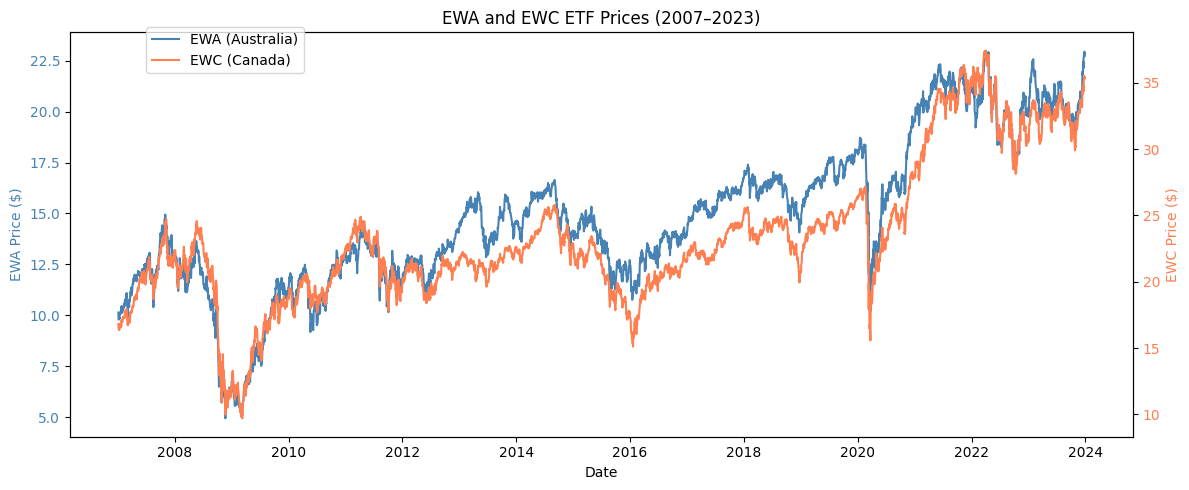

In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(ewa.index, ewa.values, color="steelblue", label="EWA (Australia)")
ax1.set_ylabel("EWA Price ($)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(ewc.index, ewc.values, color="coral", label="EWC (Canada)")
ax2.set_ylabel("EWC Price ($)", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
ax1.set_title("EWA and EWC ETF Prices (2007\u20132023)")
ax1.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 3. Engle-Granger Cointegration Test
Step 1: Regress EWC on EWA. Step 2: Test the residuals for stationarity with ADF.

In [4]:
# Regress EWC on EWA (no intercept, following the original R code)
model = OLS(ewc.values, ewa.values).fit()
spread = model.resid
print(f"Hedge ratio: {model.params[0]:.4f}")

# ADF test on the residuals
adf_stat, adf_pval, _, _, crit_vals, _ = adfuller(spread, regression="n")
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value: {adf_pval:.4f}")
print(f"Critical values: {crit_vals}")

Hedge ratio: 1.5674


ADF statistic: -3.1704
p-value: 0.0015
Critical values: {'1%': -2.5662649122761407, '5%': -1.9410632217791663, '10%': -1.6167578163676815}


## 4. Visualise the Spread
The spread should oscillate around zero if the pair is cointegrated.

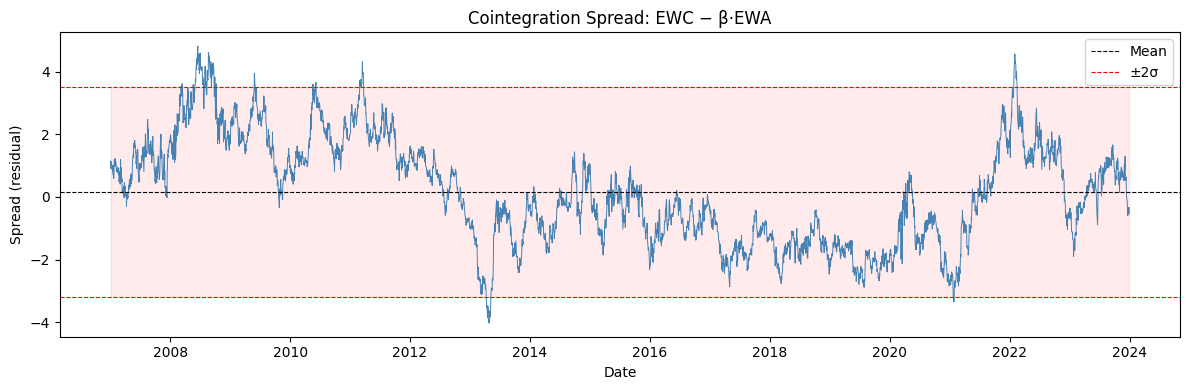

In [5]:
mu = np.mean(spread)
sigma = np.std(spread)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ewa.index, spread, color="steelblue", linewidth=0.7)
ax.axhline(mu, color="black", linestyle="--", linewidth=0.8, label="Mean")
ax.axhline(mu + 2 * sigma, color="red", linestyle="--", linewidth=0.8, label="\u00b12\u03c3")
ax.axhline(mu - 2 * sigma, color="red", linestyle="--", linewidth=0.8)
ax.fill_between(ewa.index, mu - 2 * sigma, mu + 2 * sigma, alpha=0.08, color="red")
ax.set_title("Cointegration Spread: EWC \u2212 \u03b2\u00b7EWA")
ax.set_xlabel("Date")
ax.set_ylabel("Spread (residual)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Johansen Cointegration Test
The Johansen test handles multiple time series simultaneously using a VAR framework.

In [6]:
data = np.column_stack([ewa.values, ewc.values])
result = coint_johansen(data, det_order=0, k_ar_diff=1)

print("Johansen Trace Test:")
print(f"  Trace statistic (r=0): {result.lr1[0]:.2f}")
print(f"  95% critical value:    {result.cvt[0, 1]:.2f}")
print(f"  Reject H0 (no cointegration): {result.lr1[0] > result.cvt[0, 1]}")
print(f"\n  Trace statistic (r\u22641): {result.lr1[1]:.2f}")
print(f"  95% critical value:    {result.cvt[1, 1]:.2f}")

Johansen Trace Test:
  Trace statistic (r=0): 16.66
  95% critical value:    15.49
  Reject H0 (no cointegration): True

  Trace statistic (r≤1): 2.16
  95% critical value:    3.84


## 6. Comparison: GLD vs GDX (Non-Cointegrated Pair)
Despite the obvious connection between gold and gold miners, company-specific risks break the long-run equilibrium.

In [7]:
gld = yf.download("GLD", start="2007-01-01", end="2023-12-31",
                   auto_adjust=True, progress=False)["Close"]
gdx = yf.download("GDX", start="2007-01-01", end="2023-12-31",
                   auto_adjust=True, progress=False)["Close"]

common_gg = gld.index.intersection(gdx.index)
gld, gdx = gld.loc[common_gg], gdx.loc[common_gg]

# Engle-Granger on GLD/GDX
model_gg = OLS(gdx.values, gld.values).fit()
spread_gg = model_gg.resid
adf_gg, pval_gg, _, _, crit_gg, _ = adfuller(spread_gg, regression="n")

print("GLD/GDX Engle-Granger:")
print(f"  ADF statistic: {adf_gg:.4f}")
print(f"  p-value: {pval_gg:.4f}")

# Johansen on GLD/GDX
data_gg = np.column_stack([gld.values, gdx.values])
result_gg = coint_johansen(data_gg, det_order=0, k_ar_diff=1)
print(f"\nGLD/GDX Johansen Trace (r=0): {result_gg.lr1[0]:.2f} vs 95% CV: {result_gg.cvt[0, 1]:.2f}")
print(f"Reject H0: {result_gg.lr1[0] > result_gg.cvt[0, 1]}")

GLD/GDX Engle-Granger:
  ADF statistic: -1.6381
  p-value: 0.0958

GLD/GDX Johansen Trace (r=0): 13.38 vs 95% CV: 15.49
Reject H0: False


## 7. ADF Test Summary Comparison

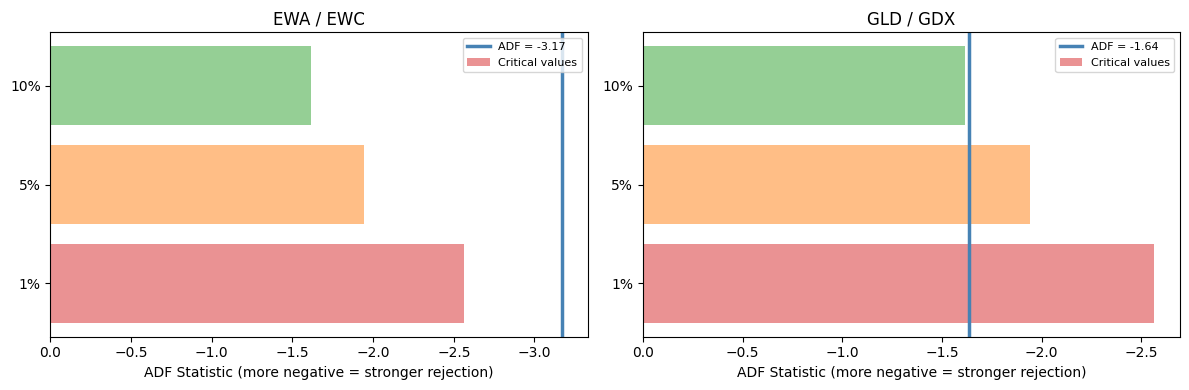

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, stat, crit) in zip(axes, [
    ("EWA / EWC", adf_stat, crit_vals),
    ("GLD / GDX", adf_gg, crit_gg)
]):
    levels = ["1%", "5%", "10%"]
    cv = [crit[l] for l in levels]
    colors = ["#d62728", "#ff7f0e", "#2ca02c"]
    
    ax.barh(levels, cv, color=colors, alpha=0.5, label="Critical values")
    ax.axvline(stat, color="steelblue", linewidth=2.5, label=f"ADF = {stat:.2f}")
    ax.set_xlabel("ADF Statistic (more negative = stronger rejection)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.invert_xaxis()

plt.tight_layout()
plt.show()

## 8. Pairs Trading Strategy
Use a rolling z-score of the spread. Buy when z < -2 (spread is cheap), sell when z > +2 (spread is expensive), close at z = 0.

In [9]:
window = 60
roll_mean = pd.Series(spread).rolling(window).mean()
roll_std = pd.Series(spread).rolling(window).std()
zscore = (spread - roll_mean) / roll_std

# Generate positions
position = np.zeros(len(zscore))
for i in range(1, len(zscore)):
    if zscore.iloc[i] < -2:
        position[i] = 1   # Buy spread
    elif zscore.iloc[i] > 2:
        position[i] = -1  # Sell spread
    elif position[i-1] == 1 and zscore.iloc[i] > 0:
        position[i] = 0   # Close long
    elif position[i-1] == -1 and zscore.iloc[i] < 0:
        position[i] = 0   # Close short
    else:
        position[i] = position[i-1]

# Compute PnL
spread_diff = np.diff(spread)
pnl = position[:-1] * spread_diff
cum_pnl = np.cumsum(pnl)

n_trades = np.sum(np.abs(np.diff(position)) > 0)
daily_ret = pnl[pnl != 0]
sharpe = np.mean(daily_ret) / np.std(daily_ret) * np.sqrt(252) if len(daily_ret) > 0 else 0

print(f"Total PnL: ${cum_pnl[-1]:.2f}")
print(f"Number of trades: {int(n_trades)}")
print(f"Annualised Sharpe: {sharpe:.2f}")

Total PnL: $19.38
Number of trades: 135
Annualised Sharpe: 0.69


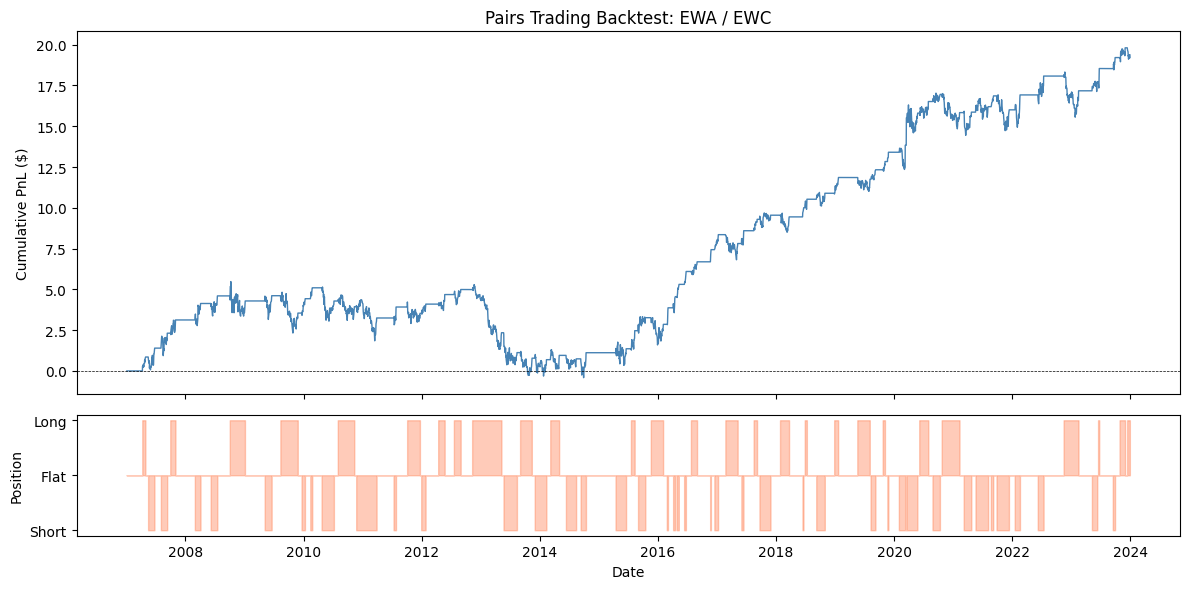

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(ewa.index[1:], cum_pnl, color="steelblue", linewidth=1)
ax1.set_ylabel("Cumulative PnL ($)")
ax1.set_title("Pairs Trading Backtest: EWA / EWC")
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")

ax2.fill_between(ewa.index, position, step="mid", alpha=0.4, color="coral")
ax2.set_ylabel("Position")
ax2.set_xlabel("Date")
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(["Short", "Flat", "Long"])

plt.tight_layout()
plt.show()

## 9. Autocorrelation of the Spread
A stationary spread should show slowly decaying autocorrelation.

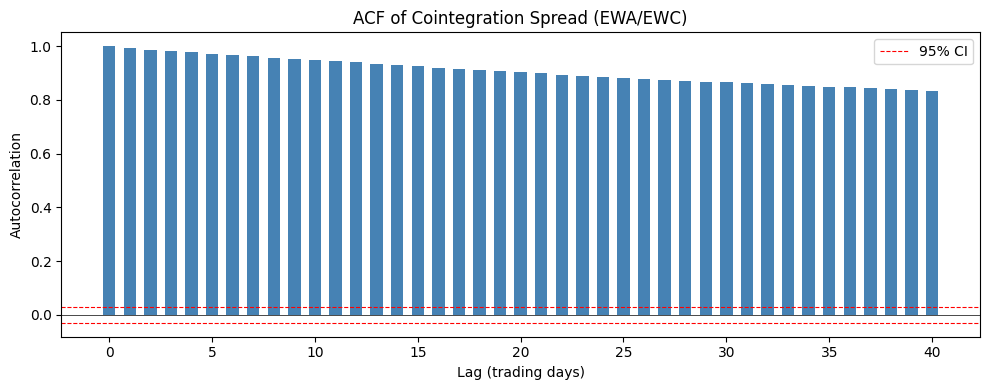

In [11]:
nlags = 40
acf_vals = acf(spread, nlags=nlags, fft=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(nlags + 1), acf_vals, color="steelblue", width=0.6)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(1.96 / np.sqrt(len(spread)), color="red", linestyle="--", linewidth=0.8, label="95% CI")
ax.axhline(-1.96 / np.sqrt(len(spread)), color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("Lag (trading days)")
ax.set_ylabel("Autocorrelation")
ax.set_title("ACF of Cointegration Spread (EWA/EWC)")
ax.legend()
plt.tight_layout()
plt.show()

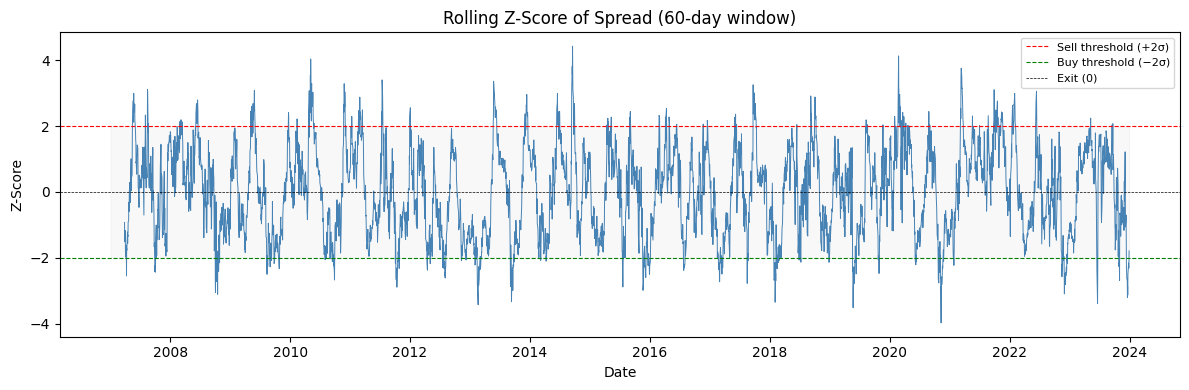

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ewa.index, zscore, color="steelblue", linewidth=0.7)
ax.axhline(2, color="red", linestyle="--", linewidth=0.8, label="Sell threshold (+2\u03c3)")
ax.axhline(-2, color="green", linestyle="--", linewidth=0.8, label="Buy threshold (\u22122\u03c3)")
ax.axhline(0, color="black", linestyle="--", linewidth=0.5, label="Exit (0)")
ax.fill_between(ewa.index, -2, 2, alpha=0.05, color="grey")
ax.set_title("Rolling Z-Score of Spread (60-day window)")
ax.set_xlabel("Date")
ax.set_ylabel("Z-Score")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()